In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from pathlib import Path
from urllib.parse import urlparse
import requests

import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["mathtext.rm"] = "Times New Roman"
mpl.rcParams["axes.unicode_minus"] = False
plt.style.use("tableau-colorblind10")

#mpl.style.use('tableau-colorblind10') 

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
EST_DIR = "to_comp_withWatanabe_paper"

EST_CO2_IMAGE  = os.path.join(EST_DIR, "CO2_RE_image.xlsx")
EST_CO2_REMIND = os.path.join(EST_DIR, "CO2_RE_remind.xlsx")

EST_CH4_IMAGE  = os.path.join(EST_DIR, "CH4_RE_image.xlsx")
EST_CH4_REMIND = os.path.join(EST_DIR, "CH4_RE_remind.xlsx")

EST_N2O_IMAGE  = os.path.join(EST_DIR, "N2O_RE_image.xlsx")
EST_N2O_REMIND = os.path.join(EST_DIR, "N2O_RE_remind.xlsx")

In [8]:
# -----------------------
# our inputs (FaIR outputs)
# -----------------------
PKL_PATH  = "parameters_C_ERF_lifetime/ERF_C_lifetime_CO2CH4N2O_1001ensemble_dicts_run2026-02-23.pkl"
OURS_XLSX = "parameters_C_ERF_lifetime/ERF_C_lifetime_CO2CH4N2O_2000_2500_run2026-02-23.xlsx"

YEAR_MIN, YEAR_MAX = 2020, 2250  # set YEAR_MAX > 2150 to extend FaIR beyond Watanabe & Cherubini (2026)

SCENARIOS = [
    ("ssp126", "SSP1-2.6", "2.6"),
    ("ssp245", "SSP2-4.5", "4.5"),
    ("ssp585", "SSP5-8.5", "8.5"),
]

SHEET_MAP = {"CO2": "CO2_RE", "CH4": "CH4_RE", "N2O": "N2O_RE"}

# Y labels (mathtext) + units
# CO2 stays in ppm^-1 (FaIR native); CH4/N2O stay in ppb^-1
YLABEL_MAP = {
    "CO2": r"CO$_2$ RE (W m$^{-2}$ ppm$^{-1}$)",
    "CH4": r"CH$_4$ RE (W m$^{-2}$ ppb$^{-1}$)",
    "N2O": r"N$_2$O RE (W m$^{-2}$ ppb$^{-1}$)",
}

EST_LABEL_BASE = "Watanabe & Cherubini (2026) point value"


def _find_est_col(df: pd.DataFrame | None, token: str) -> str | None:
    """Find first column containing token (e.g., '2.6', '4.5', '8.5')."""
    if df is None:
        return None
    cols = [c for c in df.columns if isinstance(c, str) and token in c]
    return cols[0] if cols else None

### now plot 

In [4]:
def plot_re_3x1_with_uncertainty_and_est(
    gas: str,
    pkl_path: str,
    ours_xlsx: str,
    est_image_path: str | None,
    est_remind_path: str | None,
    year_min: int = 2020,
    year_max: int = 2150,
    est_end_year: int = 2150,   # Watanabe & Cherubini data end
    scenarios=SCENARIOS,
    band_q=(5, 95),
    band_alpha=0.20,
    note_no_data: str = "no data available after 2150",
    legend_panel = 1,    # <- change legend location here (0, 1, or 2)
    save_path: str | None = None,   # 
    dpi: int = 300,                 # save resolution
    save_format: str = "png"
):
    """
    3×1 subplots (one canvas).

    FaIR: median + P5–P95 band, continues until year_max
    Watanabe & Cherubini (2026): IMAGE + REMIND, always end at est_end_year

    CO2 unit handling:
      - Keep FaIR CO2 RE as ppm^-1 (native)
      - Multiply Watanabe & Cherubini CO2 RE by 1000 (so it matches ppm^-1 scale)
    """

    gas = gas.upper()
    if gas not in SHEET_MAP:
        raise ValueError(f"gas must be one of {list(SHEET_MAP.keys())}")

    # ---- Load FaIR ensemble pickle ----
    with open(pkl_path, "rb") as f:
        payload = pickle.load(f)

    ensemble_key_map = {
        "CO2": "co2_all_ensemble_dict",
        "CH4": "ch4_all_ensemble_dict",
        "N2O": "n2o_all_ensemble_dict",
    }
    ens_dict = payload[ensemble_key_map[gas]]["gas_re"]  # dict: ssp -> (year, ensemble)

    # ---- Load FaIR median workbook sheet ----
    df_ours = pd.read_excel(ours_xlsx, sheet_name=SHEET_MAP[gas])
    df_ours.columns = df_ours.columns.str.strip()

    # ---- Load Watanabe & Cherubini (2026) (local paths) ----
    df_img = None
    df_rem = None
    if est_image_path:
        df_img = pd.read_excel(est_image_path)
        df_img.columns = df_img.columns.str.strip()
    if est_remind_path:
        df_rem = pd.read_excel(est_remind_path)
        df_rem.columns = df_rem.columns.str.strip()

    qlo, qhi = band_q

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

    GAS_TITLE = {"CO2": r"CO$_2$", "CH4": r"CH$_4$", "N2O": r"N$_2$O"}

    for i, (ax, (ssp_key, scen_label, est_token)) in enumerate(zip(axes, scenarios)):
        years = df_ours["Year"].to_numpy(dtype=float)

        # FaIR median + ensemble
        if ssp_key not in df_ours.columns:
            raise KeyError(f"'{ssp_key}' not found in '{SHEET_MAP[gas]}' sheet. Columns: {list(df_ours.columns)}")
        fair_med = df_ours[ssp_key].to_numpy(dtype=float)

        if ssp_key not in ens_dict:
            raise KeyError(f"'{ssp_key}' not found in ensemble dict for {gas}. Keys: {list(ens_dict.keys())}")
        ens = np.asarray(ens_dict[ssp_key], dtype=float)  # (year, ensemble)

        p_lo = np.percentile(ens, qlo, axis=1)
        p_hi = np.percentile(ens, qhi, axis=1)

        # plot windows
        mask_fair = (years >= year_min) & (years <= year_max)
        mask_est  = (years >= year_min) & (years <= min(year_max, est_end_year))

        # dynamic legend postion  

        band_label = f"FaIR {qlo}–{qhi}%" if i == legend_panel else "_nolegend_"
        fair_label = "FaIR median" if i == legend_panel else "_nolegend_"
        img_label  = f"{EST_LABEL_BASE}; IMAGE" if i == legend_panel else "_nolegend_"
        rem_label  = f"{EST_LABEL_BASE}; REMIND" if i == legend_panel else "_nolegend_"
        
        

        ax.fill_between(
            years[mask_fair], p_lo[mask_fair], p_hi[mask_fair],
            alpha=band_alpha, color="lightblue", label=band_label
        )
        ax.plot(years[mask_fair], fair_med[mask_fair], label=fair_label)

        # Watanabe & Cherubini (2026) overlays
        img_col = _find_est_col(df_img, est_token)
        rem_col = _find_est_col(df_rem, est_token)

        est_img = None
        est_rem = None

        if (df_img is not None) and (img_col is not None) and ("Year" in df_img.columns):
            est_img = pd.to_numeric(
                df_img.set_index("Year")[img_col].reindex(years), errors="coerce"
            ).to_numpy()
            if gas == "CO2":
                est_img *= 1000.0
            ax.plot(years[mask_est], est_img[mask_est], label=img_label)

        if (df_rem is not None) and (rem_col is not None) and ("Year" in df_rem.columns):
            est_rem = pd.to_numeric(
                df_rem.set_index("Year")[rem_col].reindex(years), errors="coerce"
            ).to_numpy()
            if gas == "CO2":
                est_rem *= 1000.0
            ax.plot(years[mask_est], est_rem[mask_est], label=rem_label)

        # If FaIR extends beyond EST, annotate between the two EST endpoints
        if i == 0:
        #if (year_max > est_end_year) and (est_img is not None) and (est_rem is not None):
            idxs = np.where(years == float(est_end_year))[0]
            if len(idxs) > 0:
                idx_end = int(idxs[0])
                y1, y2 = est_img[idx_end], est_rem[idx_end]
                if np.isfinite(y1) and np.isfinite(y2):
                    ax.text(
                        est_end_year + 2,
                        (y1 + y2) / 2,
                        note_no_data,
                        fontsize=12,
                        va="center",
                        ha="left",
                    )

        ax.set_title(f"{GAS_TITLE[gas]} radiative efficiency: {scen_label} ", fontsize=16) #({year_min}–{year_max})
        ax.set_ylabel(YLABEL_MAP[gas], fontsize=14)
        ax.grid(True)

        # CO2 now ~1e-2 (ppm^-1), so don't force scilimits to -5
        ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

        if i == legend_panel :
            ax.legend(fontsize=14)

    axes[-1].set_xlabel("Year")


    # ✅ Save if requested (save_path = folder)
    if save_path:
        import os

        os.makedirs(save_path, exist_ok=True)

        if save_format is None:
            save_format = "png"

        fmt = save_format.lower()
        filename = f"{gas}_RE.{fmt}"
        final_path = os.path.join(save_path, filename)

        if fmt in ["tif", "tiff"]:
            fig.savefig(
                final_path,
                format="tiff",
                dpi=dpi,
                bbox_inches="tight",
                pil_kwargs={"compression": "tiff_lzw"},
            )
        else:
            fig.savefig(
                final_path,
                format=fmt,
                dpi=dpi,
                bbox_inches="tight",
            )


            
    fig.tight_layout()
    #return fig

## CO2

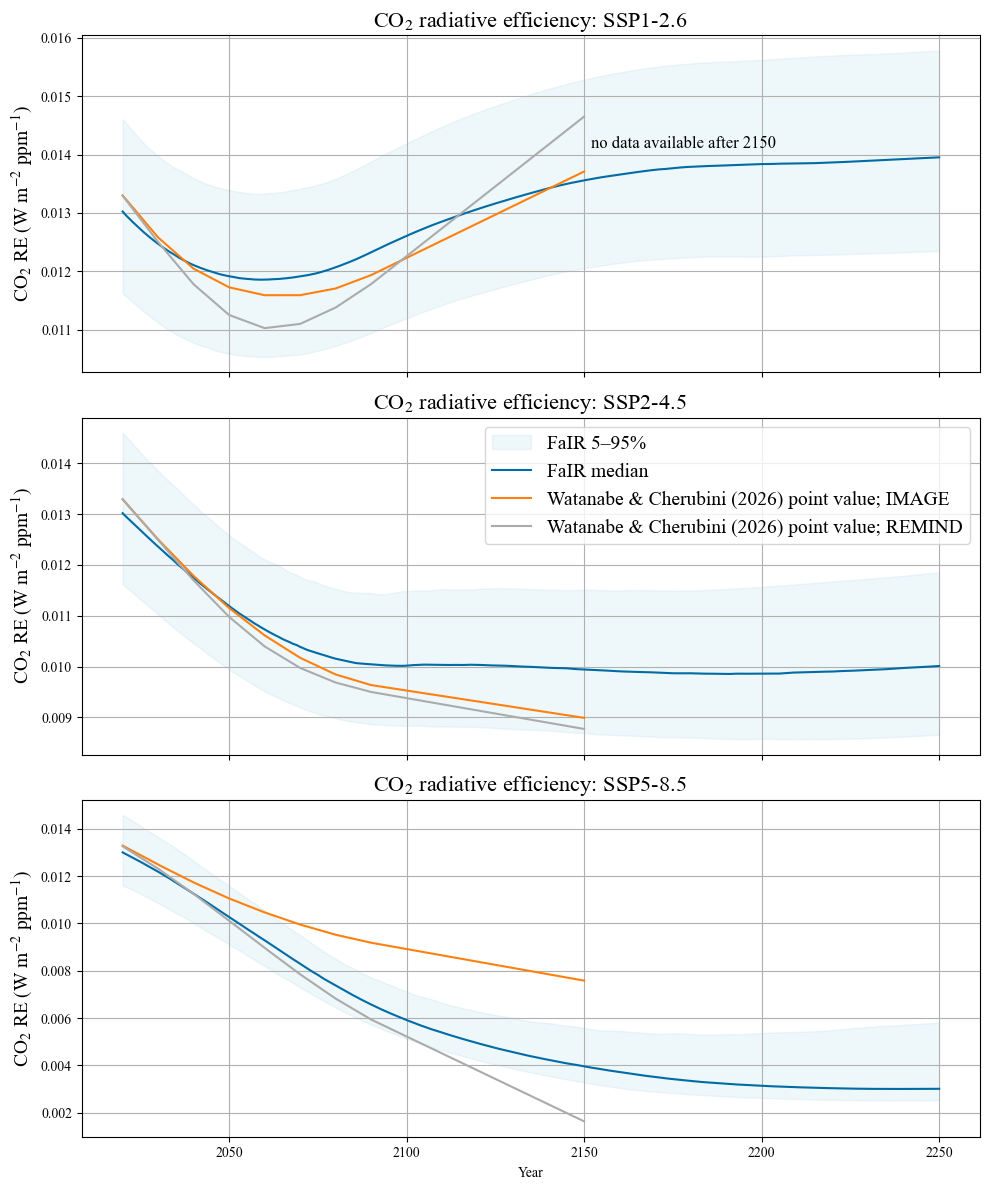

In [5]:
plot_re_3x1_with_uncertainty_and_est(
    gas="CO2",
    pkl_path=PKL_PATH,
    ours_xlsx=OURS_XLSX,
    est_image_path = "to_comp_withWatanabe_paper/CO2_RE_image.xlsx",  
    est_remind_path =   "to_comp_withWatanabe_paper/CO2_RE_remind.xlsx",  
    year_min=YEAR_MIN,
    year_max=YEAR_MAX,
    save_path = "RE_plot",
    dpi = 600, 
    save_format = "tiff"
)

## CH4

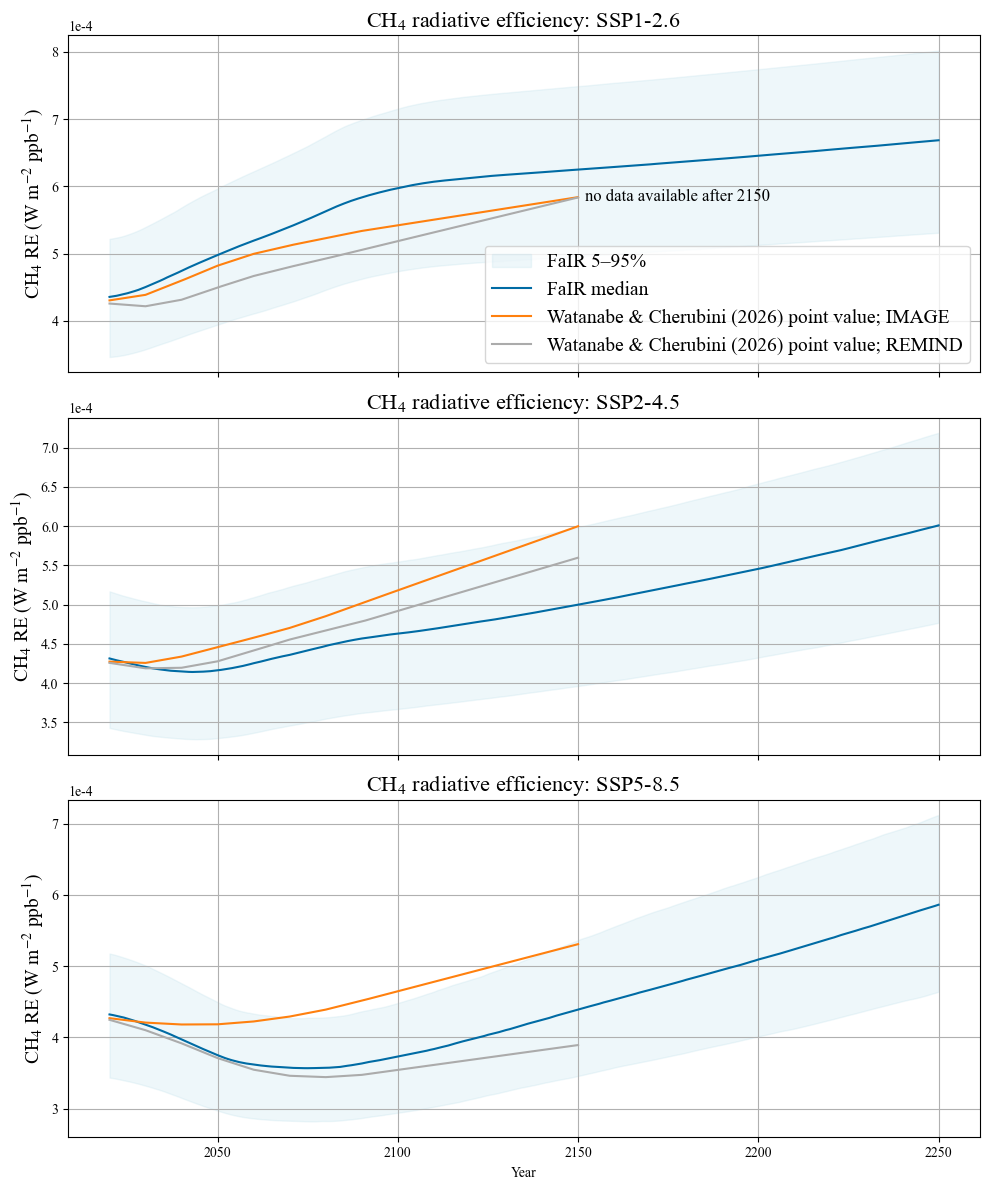

In [6]:
# CH4
plot_re_3x1_with_uncertainty_and_est(
    gas="CH4",
    pkl_path=PKL_PATH,
    ours_xlsx=OURS_XLSX,
    est_image_path = "to_comp_withWatanabe_paper/CH4_RE_image.xlsx",  
    est_remind_path =   "to_comp_withWatanabe_paper/CH4_RE_remind.xlsx",  
    year_min=YEAR_MIN,
    year_max=YEAR_MAX,
    legend_panel = 0,    
    save_path = "RE_plot", 
    dpi = 600, 
    save_format = "tiff"
)


## N2O 

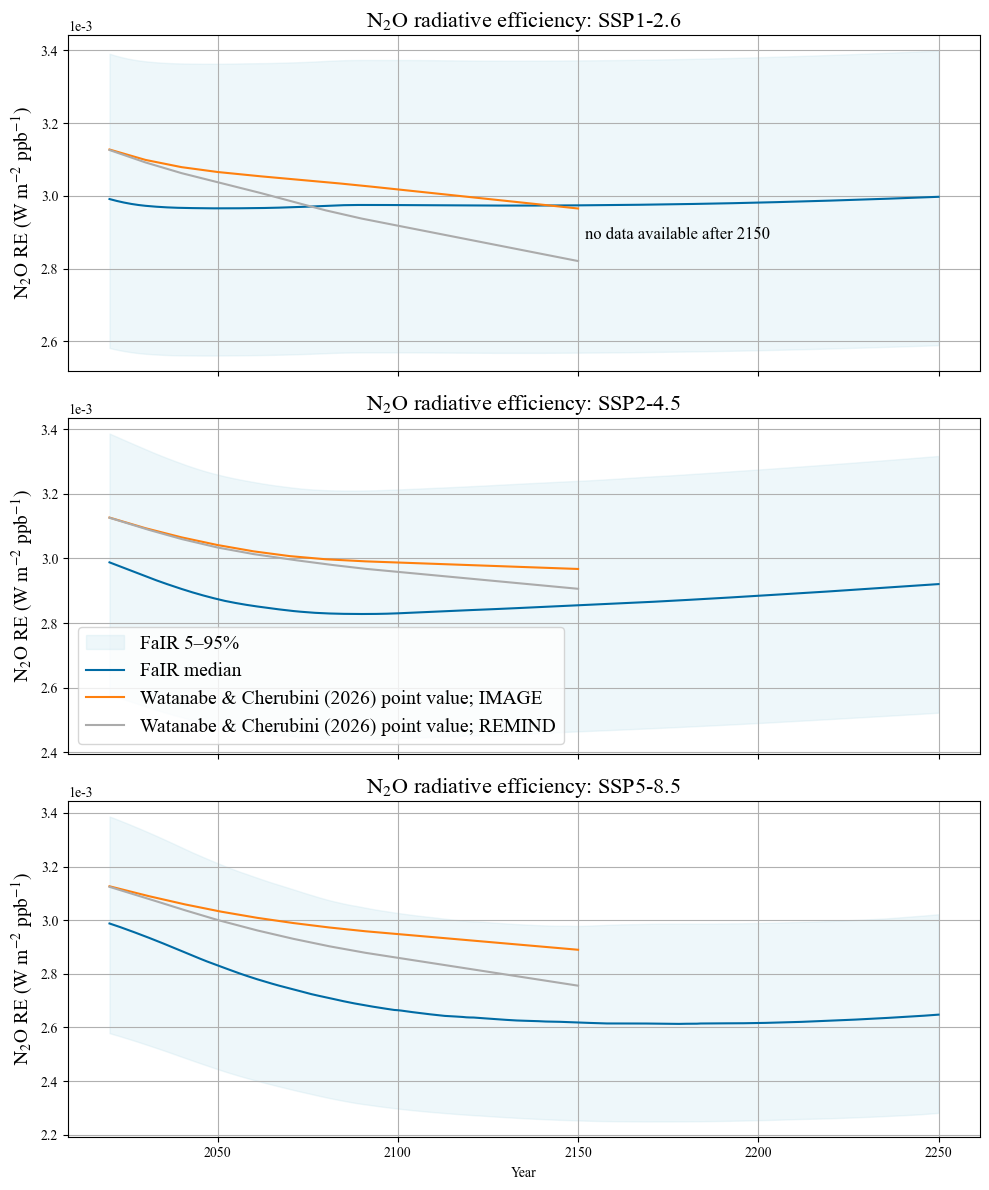

In [9]:
# N2O, there;s a naming issue in our FaIR worksheet for N2O, manually corrected 
plot_re_3x1_with_uncertainty_and_est(
    gas="N2O",
    pkl_path=PKL_PATH,
    ours_xlsx=OURS_XLSX,
    est_image_path = "to_comp_withWatanabe_paper/N2O_RE_image.xlsx",  
    est_remind_path = "to_comp_withWatanabe_paper/N2O_RE_remind.xlsx",  
    year_min=YEAR_MIN,
    year_max=YEAR_MAX,
)
plt.show()